In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. ANÁLISE EXPLORATÓRIA DE DADOS

In [3]:
df = pd.read_csv('manutencao_preditiva.csv')

In [4]:
#Dimensoes do dataset:
num_linhas, num_colunas = df.shape
print(f"O dataset possui {num_linhas} linhas e {num_colunas} colunas.")

O dataset possui 10000 linhas e 14 colunas.


In [5]:
# Tipos de dados das variáveis:

display(df.dtypes)

udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

In [6]:
#Resumo estatístico das colunas numéricas usando ".describe()":
display(df.describe())


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


1.2. ANÁLISE GRÁFICA

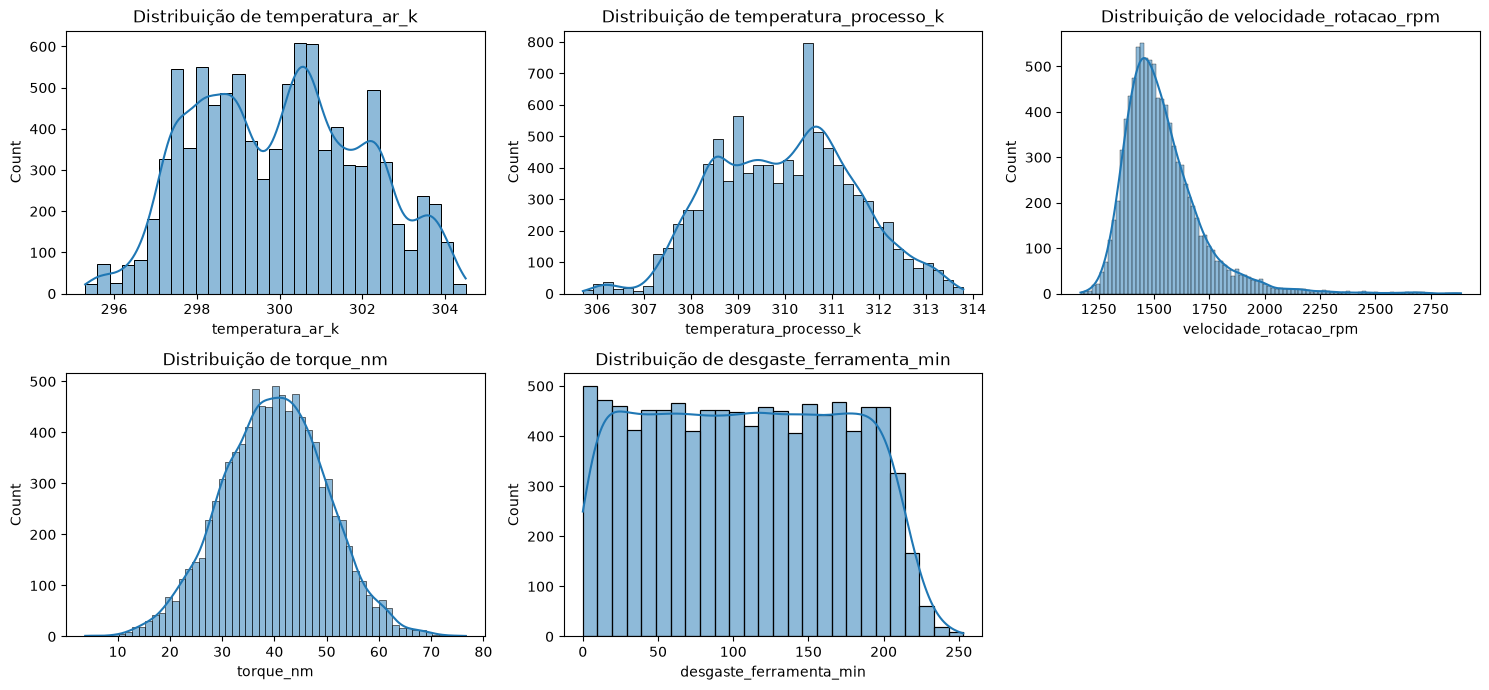

In [7]:
#HISTOGRAMA PARA DEMONSTRAÇÃO DA DISTRIBUIÇÃO DE VARIÁVEIS PREDITORAS:
predictive_features = df.drop(columns=['udi','falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']).select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(predictive_features):
    plt.subplot(3, 3, i + 1) # Ajuste o grid conforme o número de variáveis
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

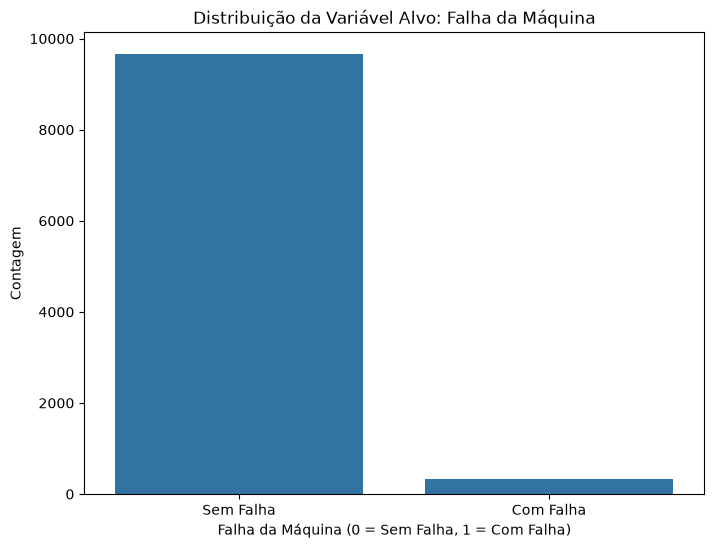

Porcentagem de máquinas sem falha: 96.61%
Porcentagem de máquinas com falha: 3.39%


In [8]:
#GRÁFICO BARRAS PARA DEMONSTRAR O DESBALANCEAMENTO DA VARIÁVEL ALVO:

plt.figure(figsize=(8, 6))
sns.countplot(x='falha_maquina', data=df)
plt.title('Distribuição da Variável Alvo: Falha da Máquina')
plt.xlabel('Falha da Máquina (0 = Sem Falha, 1 = Com Falha)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Sem Falha', 'Com Falha'])
plt.show()

falha_counts = df['falha_maquina'].value_counts(normalize=True) * 100
print(f"Porcentagem de máquinas sem falha: {falha_counts[0]:.2f}%")
print(f"Porcentagem de máquinas com falha: {falha_counts[1]:.2f}%")

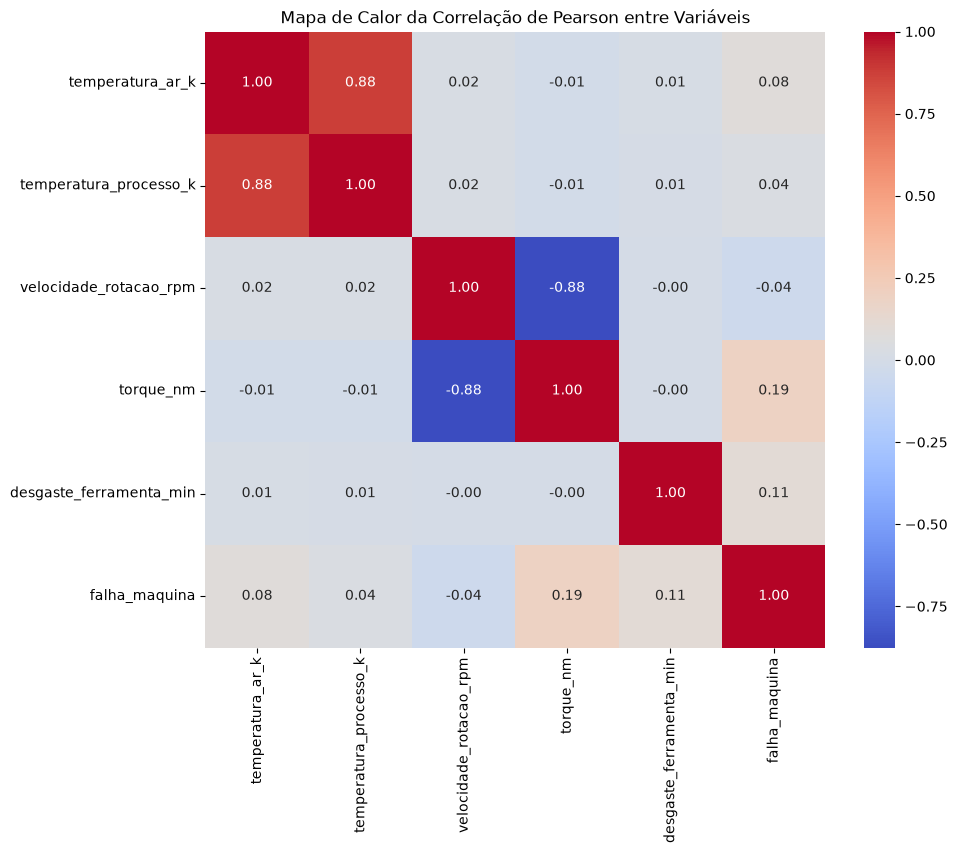

In [9]:
# MAPA DE CALOR - CORRELAÇÃO DE PEARSON:
# Excluídas as colunas de identificação e colunas de falha que não são a variável alvo.

correlation_features = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina']
plt.figure(figsize=(10, 8))
sns.heatmap(df[correlation_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor da Correlação de Pearson entre Variáveis')
plt.show()

Conclusões sobre os gráficos previamente gerados:
1. As curvas de "sino" mostram a distribuição normal (estatística) das variáveis contínuas, em geral simétricas com ligeira assimetria em alguns casos e picos em baixa frequencia para velocidade de rotação e torque, como esperado, pois faz sentido que máquinas operem em condições normais, não em extremos, o que certamente causaria maior desgaste e falhas, por consequência. 
2. O gráfico de barras comprova o desbalanceamento dos dados, e uma taxa de falha abaixo de 4%.
3. Para este modelo, o mapa de calor de Pearson apresenta correlação da variável alvo com o desgaste da ferramenta e o torque, e a relação inversa do torque com a velocidade. Além disso, ele também indica a multicolinearidade entre as temperaturas, o que pode afetar alguns modelos lineares.

2. DATA PREP - LIMPEZA E TRATAMENTO DE DADOS

In [10]:
# Remover linhas duplicadas
linhas_duplicadas = df.duplicated().sum()
print(f"Número de linhas duplicadas encontradas: {linhas_duplicadas}")

if linhas_duplicadas > 0:
    df_cleaned = df.drop_duplicates().copy()
    print(f"Número de linhas após a remoção de duplicadas: {len(df_cleaned)}")
else:
    df_cleaned = df.copy()
    print("Nenhuma linha duplicada encontrada.")

# Para atualizar o DataFrame principal
df = df_cleaned 


Número de linhas duplicadas encontradas: 0
Nenhuma linha duplicada encontrada.


In [11]:
# Tratar dados ausentes, preenchendo com a média ou mediana.

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

print("Dados ausentes por coluna:")
if not missing_data.empty:
    display(missing_data)

    # Imputar dados ausentes em colunas numéricas
    numeric_cols_with_missing = df[missing_data.index].select_dtypes(include=['number']).columns

    if not numeric_cols_with_missing.empty:
        print("Imputando dados ausentes em colunas numéricas...")
        for col in numeric_cols_with_missing:
            
    # Como visto anteriormente, as variáveis 'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm' e 'torque_nm' apresentam distribuições normal, com uma ligeira assimetria, e portanto preencher os dados com a média seria uma escolha razoável.
    # Porém, vamos calcular a skewness (assimetria) para verificar.
            
            # Verificando assimetria
            assimetria = df[col].skew()
            print(f"Assimetria da coluna '{col}': {assimetria:.2f}")

            if abs(assimetria) > 0.5:  # Parâmetro que indica assimetria significativa
                df[col] = df[col].fillna(df[col].median())
                print(f"Dados ausentes na coluna '{col}' completados com a MEDIANA devido à distribuição assimétrica.")
            else:
                df[col] = df[col].fillna(df[col].mean())
                print(f"Dados ausentes na coluna '{col}' completados com a MÉDIA devido à distribuição simétrica.")
    else:
        print("Não há colunas numéricas com dados ausentes.")
   
else:
    print("Nenhum dado ausente encontrado.")

print("Verificação final de dados ausentes:")
display(df.isnull().sum())

Dados ausentes por coluna:


temperatura_ar_k          500
temperatura_processo_k    500
velocidade_rotacao_rpm    500
torque_nm                 500
dtype: int64

Imputando dados ausentes em colunas numéricas...
Assimetria da coluna 'temperatura_ar_k': 0.11
Dados ausentes na coluna 'temperatura_ar_k' completados com a MÉDIA devido à distribuição simétrica.
Assimetria da coluna 'temperatura_processo_k': 0.02
Dados ausentes na coluna 'temperatura_processo_k' completados com a MÉDIA devido à distribuição simétrica.
Assimetria da coluna 'velocidade_rotacao_rpm': 1.99
Dados ausentes na coluna 'velocidade_rotacao_rpm' completados com a MEDIANA devido à distribuição assimétrica.
Assimetria da coluna 'torque_nm': -0.01
Dados ausentes na coluna 'torque_nm' completados com a MÉDIA devido à distribuição simétrica.
Verificação final de dados ausentes:


udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64

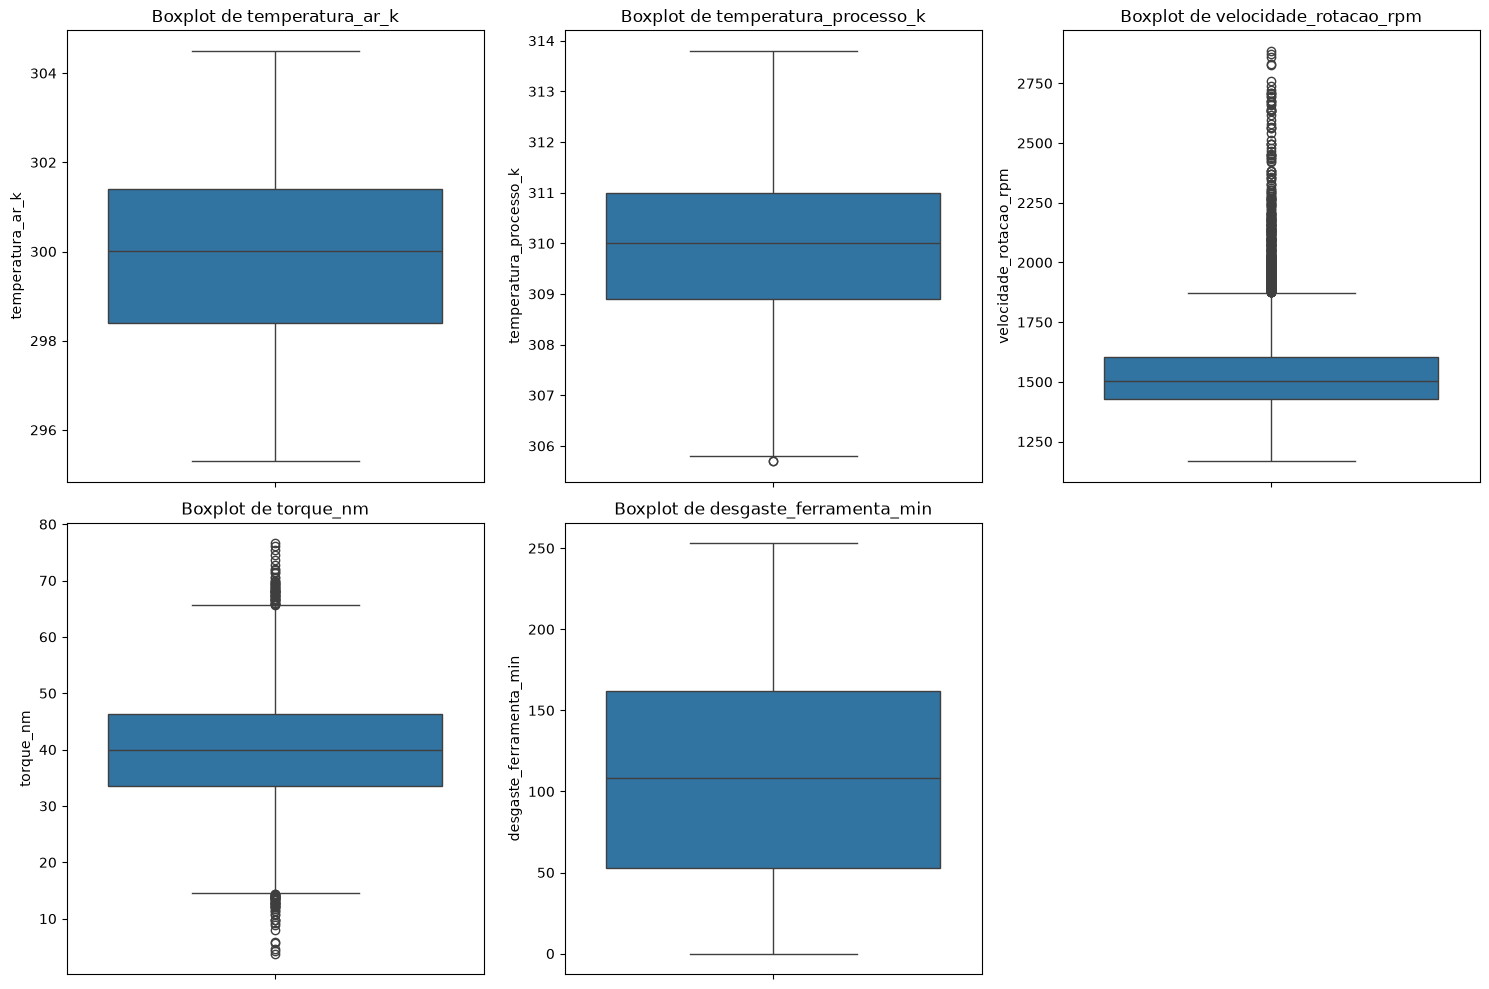

In [12]:
#GRÁFICO BOXPLOT - IDENTIFICAÇÃO DE OUTLIERS

# Considerar somente colunas numéricas explicativas e excluir colunas de id, alvo e outras falhas de caráter informativo
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
explanatory_numeric_cols = [col for col in numeric_cols if col not in ['udi', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']]

plt.figure(figsize=(15, 10))
for i, col in enumerate(explanatory_numeric_cols):
    plt.subplot(2, 3, i + 1) 
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

3. FEATURE ENGINEERING 
obs.: dados nulos e ausentes já foram tratados previamente

In [13]:
# Criando uma variável Potência:

df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']
print("Coluna 'potencia' criada com sucesso.")
display(df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head())

Coluna 'potencia' criada com sucesso.


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.800000,66382.800000
1,1408.0,46.300000,65190.400000
2,1498.0,49.400000,74001.200000
3,1504.0,39.974168,60121.149305
4,1408.0,40.000000,56320.000000


4. DIVISÃO E BALANCEAMENTO DE DADOS

4.1 Separando as Variáveis Preditoras (X) e Alvo (y)

In [14]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Variável alvo
y = df['falha_maquina']

# Variáveis preditoras (X)
# Excluir 'udi', 'id_produto', 'falha_maquina' e as demais colunas de falha
columns_to_drop_from_X = ['udi', 'id_produto', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
X = df.drop(columns=columns_to_drop_from_X, errors='ignore')

# Aplicar One-Hot Encoding para a coluna 'tipo' (que é categórica)
X = pd.get_dummies(X, columns=['tipo'], drop_first=True)

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)
print("Primeiras linhas de X (após one-hot encoding e exclusão de colunas):")
display(X.head())

Dimensões de X: (10000, 8)
Dimensões de y: (10000,)
Primeiras linhas de X (após one-hot encoding e exclusão de colunas):


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia,tipo_L,tipo_M
0,298.100000,308.600000,1551.0,42.800000,0,66382.800000,False,True
1,298.200000,308.700000,1408.0,46.300000,3,65190.400000,True,False
2,298.100000,308.500000,1498.0,49.400000,5,74001.200000,True,False
3,300.002158,310.000895,1504.0,39.974168,7,60121.149305,True,False
4,298.200000,308.700000,1408.0,40.000000,9,56320.000000,True,False


4.2 Separando os Dados em Conjuntos de Treino e Teste

In [15]:
# Dividir os dados em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

print("Distribuição da variável alvo em y_train:")
display(y_train.value_counts(normalize=True))
print("Distribuição da variável alvo em y_test:")
display(y_test.value_counts(normalize=True))

Dimensões de X_train: (8000, 8)
Dimensões de X_test: (2000, 8)
Dimensões de y_train: (8000,)
Dimensões de y_test: (2000,)
Distribuição da variável alvo em y_train:


falha_maquina
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Distribuição da variável alvo em y_test:


falha_maquina
0    0.966
1    0.034
Name: proportion, dtype: float64

4.3 REAMOSTRAGEM COM SMOTE (Apenas nos dados de treino para evitar Data Leakage)
==> Data Leakage: quando os dados criados para teste vazam pro modelo de treino gerando métricas irreais e falhas ao processar dados novos.

In [16]:
# Instanciar o SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE APENAS no conjunto de treino
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição da variável alvo no y_train original:")
display(y_train.value_counts())
print("Distribuição da variável alvo no y_train reamostrado com SMOTE:")
display(y_train_resampled.value_counts())

Distribuição da variável alvo no y_train original:


falha_maquina
0    7729
1     271
Name: count, dtype: int64

Distribuição da variável alvo no y_train reamostrado com SMOTE:


falha_maquina
0    7729
1    7729
Name: count, dtype: int64

5. STANDARD SCALER
 
 5.1 Escalonamento das Variáveis
 
 obs.: necessário para colocar todas as variáveis numa mesma escala de forma a impedir que o modelo dê mais "peso" para as que apresentam valores maiores. E portanto, nao exclui os outliers.

In [17]:
from sklearn.preprocessing import StandardScaler

continuous_cols = X_train_resampled.select_dtypes(include=['float64', 'int64']).columns.tolist()
columns_to_scale = [col for col in X_train_resampled.columns if col not in ['tipo_L', 'tipo_M']]

# Inicializar o StandardScaler
scaler = StandardScaler()

# Aplicar StandardScaler nas variáveis contínuas dos dados de treino resampleados (para KNN)
X_train_resampled_scaled_knn = X_train_resampled.copy()
X_train_resampled_scaled_knn[columns_to_scale] = scaler.fit_transform(X_train_resampled_scaled_knn[columns_to_scale])

# Aplicar StandardScaler nas variáveis contínuas dos dados de teste (para KNN)
X_test_scaled_knn = X_test.copy()
X_test_scaled_knn[columns_to_scale] = scaler.transform(X_test_scaled_knn[columns_to_scale])

print("Dados de treino e teste escalonados para o modelo KNN.")
print("Primeiras linhas de X_train_resampled_scaled_knn:")
display(X_train_resampled_scaled_knn.head())
print("\nPrimeiras linhas de X_test_scaled_knn:")
display(X_test_scaled_knn.head())


Dados de treino e teste escalonados para o modelo KNN.
Primeiras linhas de X_train_resampled_scaled_knn:


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia,tipo_L,tipo_M
0,-0.223614,-0.118866,-0.055287,-0.331949,-1.048750,-0.289815,False,True
1,-1.819996,-1.428516,-0.413711,0.121966,0.127162,0.033965,False,True
2,0.306984,1.112408,-0.557081,0.065455,0.202541,-0.171040,False,True
3,-0.809680,-0.273551,-0.372748,0.821293,-0.596476,1.015330,True,False
4,-1.766821,-1.274521,0.726420,-1.128345,-1.109053,-0.991367,True,False



Primeiras linhas de X_test_scaled_knn:


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia,tipo_L,tipo_M
2997,0.041112,-0.273551,-0.598044,1.273383,0.443754,1.345849,True,False
4871,1.742695,1.728389,-0.024565,-0.323060,0.172390,-0.252647,True,False
3858,1.104601,0.958412,0.132459,-0.499658,1.287998,-0.391342,True,False
951,-2.564439,-2.968470,-0.038219,-0.626808,-0.958295,-0.701863,False,False
6463,0.041112,-0.119555,-0.553667,1.110913,-0.325112,1.189899,False,False


    5.2 Árvore de Decisão (sem escalonamento):

 O escalonamento não é necessário, uma vez que o modelo toma decisões baseado nos atributos, nao sendo sensível à escala dos dados. Além de desnecessário, exigiria mais recursos do sistema.


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Usar os dados de treino originais (sem SMOTE e sem escalonamento) 
dt_classifier = DecisionTreeClassifier(random_state=42)

# Treino do modelo
dt_classifier.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_dt = dt_classifier.predict(X_test)

# Avaliar o desempenho do modelo
print("Acurácia da Árvore de Decisão:", accuracy_score(y_test, y_pred_dt))


Acurácia da Árvore de Decisão: 0.9815


6. Ajuste de Parâmetros & Controle de Overfitting   

6.1 Arvore de Decisão com Parâmetro "max_depth" ("máxima profundidade")

In [19]:
max_depth_values = [3, 5, None] 
dtree_results = []

print("Ajustando o modelo de Árvore de Decisão com diferentes valores de max_depth:\n")
for depth in max_depth_values:
    # Para a Árvore de Decisão, não usamos dados escalonados (X_train_resampled, X_test)
    dtree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtree.fit(X_train_resampled, y_train_resampled)

    y_train_pred = dtree.predict(X_train_resampled)
    y_test_pred = dtree.predict(X_test)

    train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    dtree_results.append({'max_depth': depth, 'train_accuracy': train_accuracy, 'test_accuracy': test_accuracy})
    print(f"Max Depth = {depth}: Acurácia de Treino = {train_accuracy:.4f}, Acurácia de Teste = {test_accuracy:.4f}")

dtree_results_df = pd.DataFrame(dtree_results)
print("\nResultados da Árvore de Decisão:\n")
display(dtree_results_df)

Ajustando o modelo de Árvore de Decisão com diferentes valores de max_depth:

Max Depth = 3: Acurácia de Treino = 0.8581, Acurácia de Teste = 0.8595
Max Depth = 5: Acurácia de Treino = 0.9035, Acurácia de Teste = 0.9120
Max Depth = None: Acurácia de Treino = 0.9945, Acurácia de Teste = 0.9450

Resultados da Árvore de Decisão:



,max_depth,train_accuracy,test_accuracy
0,3.0,0.858132,0.8595
1,5.0,0.903545,0.9120
2,NaN,0.994501,0.9450


    6.2 KNN model

In [20]:
from sklearn.neighbors import KNeighborsClassifier
k_values = [3, 5, 7] # Valores ímpares de K
knn_results = []

print("Ajustando o modelo KNN com diferentes valores de n_neighbors:\n")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_resampled_scaled_knn, y_train_resampled)

    y_train_pred = knn.predict(X_train_resampled_scaled_knn)
    y_test_pred = knn.predict(X_test_scaled_knn)

    train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    knn_results.append({'n_neighbors': k, 'train_accuracy': train_accuracy, 'test_accuracy': test_accuracy})
    print(f"K = {k}: Acurácia de Treino = {train_accuracy:.4f}, Acurácia de Teste = {test_accuracy:.4f}")

knn_results_df = pd.DataFrame(knn_results)
print("\nResultados do KNN:\n")
display(knn_results_df)

Ajustando o modelo KNN com diferentes valores de n_neighbors:



K = 3: Acurácia de Treino = 0.9710, Acurácia de Teste = 0.9140
K = 5: Acurácia de Treino = 0.9608, Acurácia de Teste = 0.9095
K = 7: Acurácia de Treino = 0.9546, Acurácia de Teste = 0.9020

Resultados do KNN:



,n_neighbors,train_accuracy,test_accuracy
0,3,0.970954,0.9140
1,5,0.960797,0.9095
2,7,0.954587,0.9020


CONCLUSÕES ACERCA DA ACURÁCIA, ESTABILIDADE E OVERFITTING NOS MODELOS:

Na Árvore de Decisão, há indícios de overfitting quando max_depth=None, pois a acurácia de treino se aproxima de 100%. A configuração mais estável foi max_depth=3, onde os valores de acurácia para treino e teste são mais próximos, porém com baixíssimo desempenho, assim como max_depth=5. Vamos considerar max_depth=None a melhor solução para este caso.

No KNN, K=3 apresenta uma boa acurácia, porém uma diferença significativa entre as acurácias de treino e teste o que pode indicar ovefitting. K=5 e K=7 no apresentam um desempenho menor e ainda diferenças importantes entre treino e teste. Neste caso, K=3 seria a melhor opção.

7. VEREDITO

In [21]:
# 7.1 RETREINAR OS MODELOS COM OS MELHORES PARÂMETROS PARA KNN E ÁRVORE DE DECISÃO ENCONTRADOS

# Melhor KNN (K = 3, baseado na maior acurácia de teste)
best_k_knn = 3
best_knn = KNeighborsClassifier(n_neighbors=best_k_knn)
best_knn.fit(X_train_resampled_scaled_knn, y_train_resampled)
y_pred_knn = best_knn.predict(X_test_scaled_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"Acurácia final do melhor KNN (n_neighbors={best_k_knn}) nos dados de teste: {accuracy_knn:.4f}")

# Melhor Árvore de Decisão (max_depth = None, baseado na maior acurácia de teste)
best_max_depth_dtree = None
best_dtree = DecisionTreeClassifier(max_depth=best_max_depth_dtree, random_state=42)
best_dtree.fit(X_train_resampled, y_train_resampled)
y_pred_dtree = best_dtree.predict(X_test)
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)

print(f"Acurácia final da melhor Árvore de Decisão (max_depth={best_max_depth_dtree}) nos dados de teste: {accuracy_dtree:.4f}")



Acurácia final do melhor KNN (n_neighbors=3) nos dados de teste: 0.9140
Acurácia final da melhor Árvore de Decisão (max_depth=None) nos dados de teste: 0.9450


7.2 Comparação e Conclusão Final

Ao comparar as duas acurácias, é evidente que a Árvore de Decisão com max_depth=None apresentou um desempenho significativamente superior no conjunto de teste, alcançando 0.9450 de acurácia, contra 0.9140 do melhor modelo KNN. 

Além disso, a Árvore de Decisão com max_depth=None também apresenta uma boa estabilidade entre as acurácias de treino e teste.

Conclusão e recomendações:

Considerando a alta acurácia e a estabilidade demonstrada no conjunto de teste, o modelo de Árvore de Decisão configurado com max_depth=None apresenta desempenho superior e deve ser adotado pela empresa. Este modelo é capaz de prever falhas de máquina com uma taxa de acerto bastante alta no teste, essencial para aplicações de manutenção preditiva, onde a identificação precisa de falhas pode gerar economia significativa e otimização na operação.